In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
df = pd.read_csv("startup_funding_cleaned(1).csv")

In [3]:
df.head()

df.info()

df.describe()

df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2372 entries, 0 to 2371
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   SNo               2372 non-null   int64  
 1   Date              2367 non-null   object 
 2   StartupName       2372 non-null   object 
 3   IndustryVertical  2201 non-null   object 
 4   SubVertical       1436 non-null   object 
 5   CityLocation      2193 non-null   object 
 6   InvestorsName     2364 non-null   object 
 7   InvestmentType    2371 non-null   object 
 8   AmountInUSD       1525 non-null   float64
dtypes: float64(1), int64(1), object(7)
memory usage: 166.9+ KB


(2372, 9)

In [4]:
df.isnull().sum()

,0
SNo,0
Date,5
StartupName,0
IndustryVertical,171
SubVertical,936
CityLocation,179
InvestorsName,8
InvestmentType,1
AmountInUSD,847


In [5]:
df = df.dropna(
    subset=[
        "AmountInUSD",
        "CityLocation",
        "IndustryVertical",
        "InvestmentType"
    ]
)

In [7]:
df["Date"] = pd.to_datetime(df["Date"])

df["Year"] = df["Date"].dt.year

In [8]:
le_city = LabelEncoder()

le_industry = LabelEncoder()

le_type = LabelEncoder()

df["CityLocation"] = le_city.fit_transform(df["CityLocation"])

df["IndustryVertical"] = le_industry.fit_transform(df["IndustryVertical"])

df["InvestmentType"] = le_type.fit_transform(df["InvestmentType"])

In [9]:
X = df[
    [
        "Year",
        "CityLocation",
        "IndustryVertical",
        "InvestmentType"
    ]
]

y = df["AmountInUSD"]

In [10]:
X_train,X_test,y_train,y_test = train_test_split(

X,

y,

test_size=0.20,

random_state=42

)

In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["CityLocation"] = le.fit_transform(df["CityLocation"].astype(str))
df["IndustryVertical"] = le.fit_transform(df["IndustryVertical"].astype(str))
df["InvestmentType"] = le.fit_transform(df["InvestmentType"].astype(str))

In [13]:
X = df[["Year", "CityLocation", "IndustryVertical", "InvestmentType"]]

y = df["AmountInUSD"]

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
dt = DecisionTreeRegressor(

random_state=42

)

dt.fit(X_train,y_train)

pred_dt = dt.predict(X_test)

In [17]:
rf = RandomForestRegressor(

n_estimators=100,

random_state=42

)

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

In [18]:
def evaluate(name,y_true,pred):

    print("="*40)

    print(name)

    print("="*40)

    print("MAE :",mean_absolute_error(y_true,pred))

    print("RMSE :",np.sqrt(mean_squared_error(y_true,pred)))

    print("R2 Score :",r2_score(y_true,pred))

    print()

In [20]:

evaluate("Decision Tree",y_test,pred_dt)

evaluate("Random Forest",y_test,pred_rf)

Decision Tree
MAE : 21478567.429432657
RMSE : 105401894.19282897
R2 Score : -0.43279502280558524

Random Forest
MAE : 19910940.382824097
RMSE : 93227648.73564312
R2 Score : -0.12092536068380833



In [22]:
results = pd.DataFrame({

"Model":[

"Decision Tree",

"Random Forest"

],

"R2 Score":[


r2_score(y_test,pred_dt),

r2_score(y_test,pred_rf)

],

"MAE":[


mean_absolute_error(y_test,pred_dt),

mean_absolute_error(y_test,pred_rf)

]

})

results.sort_values(

by="R2 Score",

ascending=False
)

,Model,R2 Score,MAE
1,Random Forest,-0.120925,1.991094e+07
0,Decision Tree,-0.432795,2.147857e+07


In [23]:
importance = pd.DataFrame({

"Feature":X.columns,

"Importance":rf.feature_importances_

})

importance = importance.sort_values(

by="Importance",

ascending=False
)

importance

,Feature,Importance
2,IndustryVertical,0.759620
1,CityLocation,0.123031
3,InvestmentType,0.064801
0,Year,0.052548


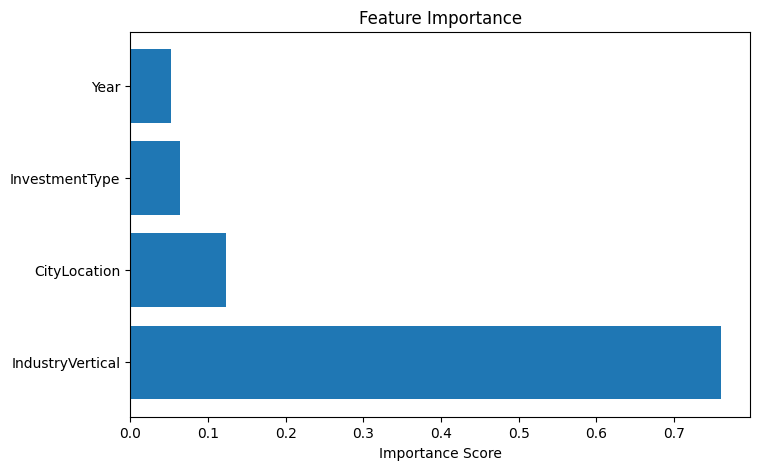

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.barh(

importance["Feature"],

importance["Importance"]

)

plt.title("Feature Importance")

plt.xlabel("Importance Score")

plt.show()

In [25]:
sample = pd.DataFrame({

"Year":[2025],

"CityLocation":[10],

"IndustryVertical":[5],

"InvestmentType":[2]

})

prediction = rf.predict(sample)

print("Predicted Funding :",prediction[0])

Predicted Funding : 34595616.08


In [26]:
import pickle

pickle.dump(

rf,

open(

"startup_funding_model.pkl",

"wb"

)

)

In [31]:
import pickle

with open("startup_funding_model.pkl", "wb") as f:
    pickle.dump(rf, f)

print("Model saved successfully!")

Model saved successfully!


In [32]:
from google.colab import files

files.download("startup_funding_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
model = pickle.load(

open(

"startup_funding_model.pkl",

"rb"

)

)

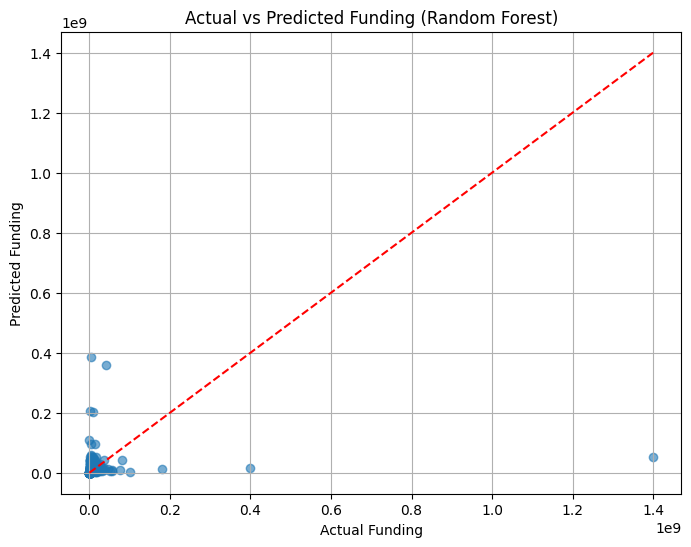

In [28]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, pred_rf, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Funding")
plt.ylabel("Predicted Funding")
plt.title("Actual vs Predicted Funding (Random Forest)")
plt.grid(True)
plt.show()

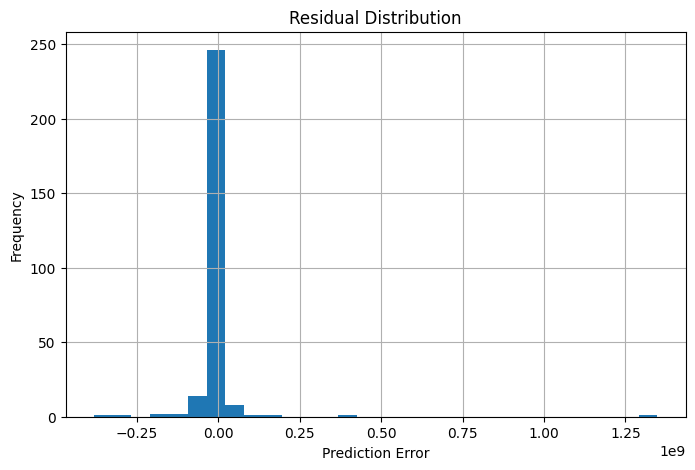

In [29]:
residuals = y_test - pred_rf

plt.figure(figsize=(8,5))

plt.hist(residuals, bins=30)

plt.title("Residual Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

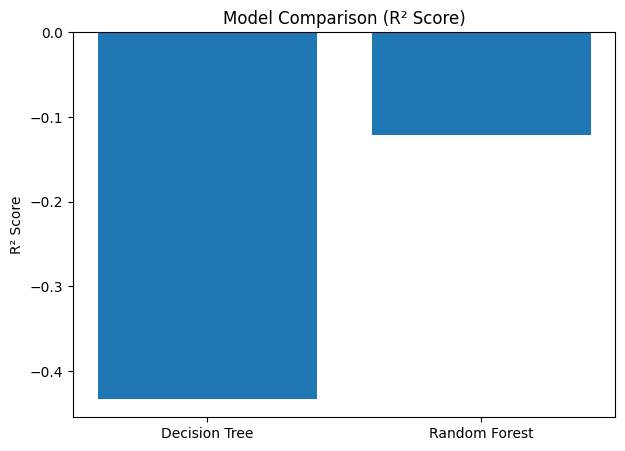

In [30]:
scores = results.set_index("Model")["R2 Score"]

plt.figure(figsize=(7,5))

plt.bar(scores.index, scores.values)

plt.title("Model Comparison (R² Score)")
plt.ylabel("R² Score")
plt.show()